# Лаборатория «Интуиция ML» — Классификация

## Логистическая регрессия от первого принципа до sklearn

> **Рекомендуемый порядок чтения:** `02_regression_intuition` → **этот ноутбук** → `03_ensembles_intuition`.
> Линейная регрессия (ноутбук 02) — это «чистый» градиентный спуск на идеальном параболоиде MSE, без сигмоиды и без вероятностной интерпретации. Здесь поверх той же логики добавляются ещё два слоя: **сигмоида** (нелинейное преобразование $z \to$ вероятность) и **log-loss** вместо MSE. Если 02 уже разобран — здесь будет совсем легко.

Мы возьмём очень простую задачу — по росту и весу определить, толстый человек или худой — и **разберём подробно, что под капотом**:

- как выглядит функция ошибки (log-loss);
- почему её градиент по весу `w_j` оказывается **пропорционален признаку `x_j`** (отсюда выражение «веса меняются пропорционально влиянию признаков»);
- как выглядит траектория градиентного спуска по поверхности ошибки;
- почему **масштабирование признаков** радикально меняет геометрию обучения;
- как `learning_rate` управляет сходимостью.

После прохождения должно быть железно понятно, почему «волшебство» антиградиента — никакое не волшебство, а простое следствие цепного правила.

## 0. Импорты

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from data_generators import make_bmi_dataset
from plotting import (
    plot_loss_surface_3d,
    plot_loss_contour,
    plot_decision_boundary,
    plot_loss_curve,
    plot_weight_evolution,
)

plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")
np.random.seed(42)

## Часть 1. Данные и интуиция

Сгенерируем 200 человек с ростом и весом. Метка: $y=1$ если **BMI = вес / рост²** больше 25 (полные),
$y=0$ иначе (худые). Добавлен ~5% шума в метках, чтобы классы немного перекрывались — это
ближе к реальности, чем идеально разделимая задача.

In [2]:
df = make_bmi_dataset(n=200, label_noise=0.05, random_state=42)
print(df.head())
print('\nРаспределение классов:')
print(df['is_fat'].value_counts())

       height     weight  is_fat
0  189.828022  91.599537       1
1  174.749530  68.589409       0
2  193.636906  86.484372       0
3  186.381561  79.505778       0
4  159.237981  66.517481       1

Распределение классов:
is_fat
0    121
1     79
Name: count, dtype: int64


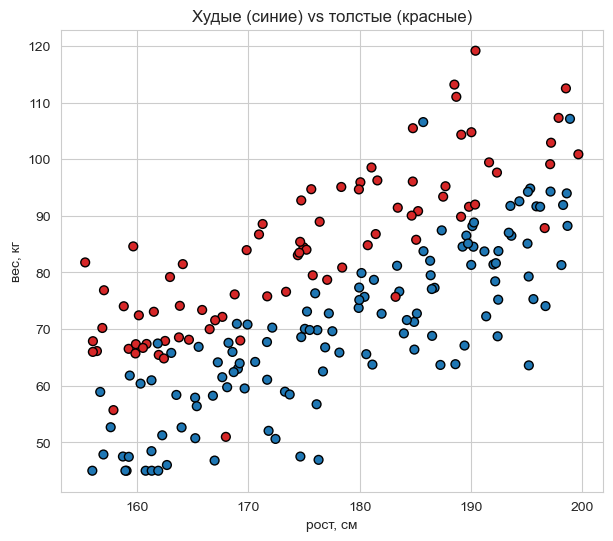

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = df['is_fat'].map({0: '#1f77b4', 1: '#d62728'})
ax.scatter(df['height'], df['weight'], c=colors, edgecolor='k', s=40)
ax.set_xlabel('рост, см')
ax.set_ylabel('вес, кг')
ax.set_title('Худые (синие) vs толстые (красные)')
plt.show()

**Глаз сразу видит:** граница между классами идёт примерно по диагонали — большой вес при том же росте → толстый.
Наша задача — найти прямую вида

$$
w_1 \cdot \text{height} + w_2 \cdot \text{weight} + b = 0
$$

которая лучше всего разделяет точки. Числа $w_1, w_2, b$ называются **весами модели**, и именно их
мы будем подбирать обучением.

## Часть 2. От прямой к вероятности — сигмоида

Если просто посчитать $z = w_1 x_1 + w_2 x_2 + b$, то $z$ — любое число от $-\infty$ до $+\infty$.
А мы хотим **вероятность** принадлежности к классу 1, то есть число от 0 до 1.

Для этого через $z$ пропускают **сигмоиду**:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

Сигмоида растёт от 0 к 1, в нуле принимает значение 0.5, симметрична относительно точки $(0, 0.5)$.
Это идеальный «squash» из бесконечной шкалы в вероятностную.

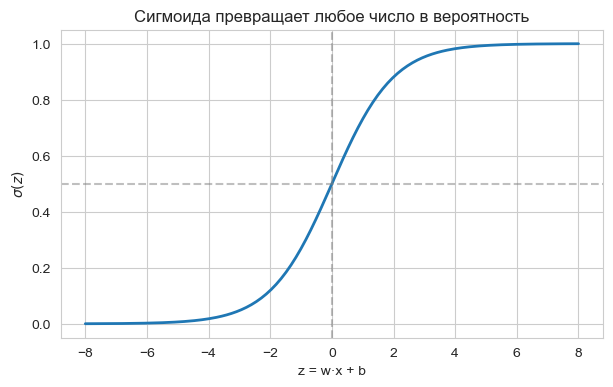

In [4]:
z = np.linspace(-8, 8, 200)
sigma = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, sigma, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('z = w·x + b')
ax.set_ylabel(r'$\sigma(z)$')
ax.set_title('Сигмоида превращает любое число в вероятность')
plt.show()

Итого: модель логистической регрессии — это $\hat{y} = P(y=1 \mid x) = \sigma(w_1 x_1 + w_2 x_2 + b)$.
Если $\hat{y} > 0.5$ — предсказываем класс 1, иначе 0.

## Часть 3. Функция ошибки — log-loss (cross-entropy)

Чтобы обучать модель, нужно **измерить, насколько плохо** она сейчас работает. Для логистической регрессии используют **log-loss**:

$$
\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \left[\, y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)\,\right].
$$

Идея: для **истинного класса 1** мы хотим $\hat{y} \to 1$, тогда $\log(\hat{y}) \to 0$, штраф маленький.
Если $\hat{y} \to 0$ при $y=1$, то $\log(\hat{y}) \to -\infty$ — штраф огромный.
Симметрично для $y=0$.

Посмотрим на штраф для **одного примера** в зависимости от предсказанной вероятности.

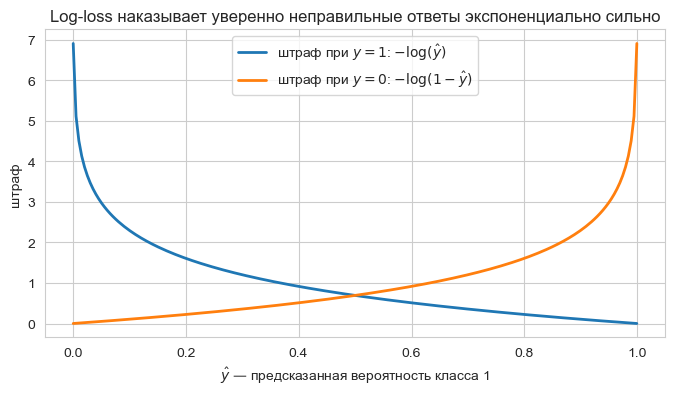

In [5]:
p = np.linspace(0.001, 0.999, 200)
loss_y1 = -np.log(p)
loss_y0 = -np.log(1 - p)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p, loss_y1, label=r'штраф при $y=1$: $-\log(\hat{y})$', linewidth=2)
ax.plot(p, loss_y0, label=r'штраф при $y=0$: $-\log(1-\hat{y})$', linewidth=2)
ax.set_xlabel(r'$\hat{y}$ — предсказанная вероятность класса 1')
ax.set_ylabel('штраф')
ax.set_title('Log-loss наказывает уверенно неправильные ответы экспоненциально сильно')
ax.legend()
plt.show()

Видно: уверенный неправильный ответ (например, $\hat{y}=0.01$ при $y=1$) даёт штраф $\sim 4.6$,
а уверенно правильный — почти 0. Промежуточное значение $\hat{y}=0.5$ даёт штраф $\log 2 \approx 0.69$.

### Главный график — поверхность функции ошибки в пространстве весов

Теперь самое интересное. Возьмём наш реальный датасет и посмотрим, как $\mathcal{L}$ зависит от весов $(w_1, w_2)$ при фиксированном $b$ (для наглядности зафиксируем $b$ в его оптимуме).

Это и есть та самая «гора ошибки», по которой мы будем спускаться градиентным спуском. **Минимум хорошо виден глазом** — но именно это и есть ответ на вопрос «как мы знаем, что в этой точке минимум»: для задач линейной/логистической регрессии loss-поверхность **математически выпуклая**, и минимум один.

In [6]:
X = df[['height', 'weight']].to_numpy()
y = df['is_fat'].to_numpy()

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def log_loss(X, y, w, b):
    z = X @ w + b
    p = sigmoid(z)
    eps = 1e-12
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

# найдём оптимальное b с помощью sklearn (только чтобы зафиксировать его на хорошем уровне)
_lr = LogisticRegression(penalty=None, max_iter=5000).fit(X, y)
b_fixed = _lr.intercept_[0]
print(f'Зафиксируем b = {b_fixed:.3f} (оптимальное значение по sklearn)')
print(f'Соответствующие оптимальные веса: w1={_lr.coef_[0,0]:.4f}, w2={_lr.coef_[0,1]:.4f}')

Зафиксируем b = 32.785 (оптимальное значение по sklearn)
Соответствующие оптимальные веса: w1=-0.3326, w2=0.3327


In [7]:
def loss_surface(w1, w2):
    return log_loss(X, y, np.array([w1, w2]), b_fixed)

w1_range = np.linspace(-0.4, 0.4, 50)
w2_range = np.linspace(-0.2, 0.4, 50)

fig = plot_loss_surface_3d(loss_surface, w1_range, w2_range,
                           title='Log-loss как функция (w1, w2) — крути мышкой',
                           w1_name='w1 (рост)', w2_name='w2 (вес)')
fig.show()

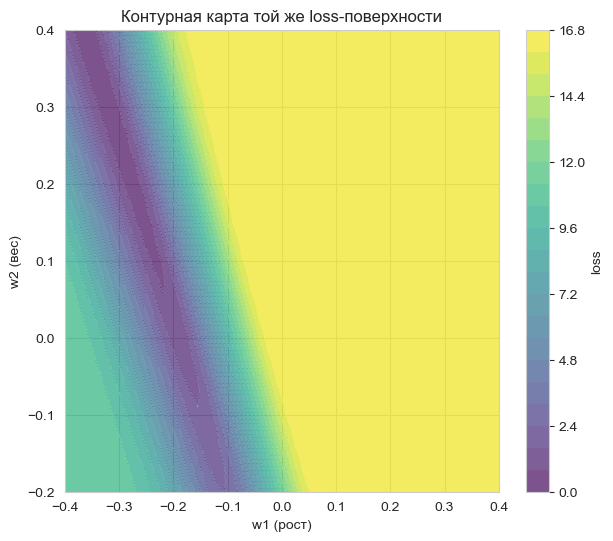

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_loss_contour(loss_surface, w1_range, w2_range, ax=ax,
                  title='Контурная карта той же loss-поверхности',
                  w1_name='w1 (рост)', w2_name='w2 (вес)')
plt.show()

Обрати внимание: контуры **сильно вытянуты** по оси $w_1$ (рост). Это потому, что значения роста (155–200) в десятки раз больше значений веса (45–120) — а градиент по $w_1$, как мы сейчас увидим, пропорционален именно `height`. Запомни эту картинку — мы вернёмся к ней в разделе про скейлинг.

## Часть 4. Откуда берётся «пропорциональность признаку» (ключевой раздел)

### Вывод градиента на бумаге

Пишем функцию ошибки для **одного примера**:

$$
\ell = -\bigl[\, y \log(\hat{y}) + (1-y)\log(1-\hat{y})\,\bigr], \quad
\hat{y} = \sigma(z), \quad z = w_1 x_1 + w_2 x_2 + b.
$$

Применяем цепное правило:

$$
\frac{\partial \ell}{\partial w_j} = \frac{\partial \ell}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w_j}.
$$

Считаем по очереди:

1. $\dfrac{\partial \ell}{\partial \hat{y}} = -\dfrac{y}{\hat{y}} + \dfrac{1-y}{1-\hat{y}} = \dfrac{\hat{y} - y}{\hat{y}(1-\hat{y})}.$
2. $\dfrac{\partial \hat{y}}{\partial z} = \sigma'(z) = \sigma(z)(1 - \sigma(z)) = \hat{y}(1-\hat{y}).$
3. $\dfrac{\partial z}{\partial w_j} = x_j.$

Перемножаем — **знаменатели сокращаются**, и получается красивая формула:

$$
\boxed{\frac{\partial \ell}{\partial w_j} = (\hat{y} - y) \cdot x_j.}
$$

Усреднение по $n$ примерам даёт коэффициент $\dfrac{1}{n}$:

$$
\frac{\partial \mathcal{L}}{\partial w_j} = \frac{1}{n}\sum_{i=1}^n (\hat{y}_i - y_i) \cdot x_{ij}.
$$

### Почему это и есть «пропорционально влиянию признака»

Смотри на формулу $\dfrac{\partial \ell}{\partial w_j} = (\hat{y} - y) \cdot x_j$:

- $(\hat{y} - y)$ — это **ошибка**: насколько мы промахнулись с вероятностью.
- $x_j$ — значение **j-го признака** для этого примера.

Чем **больше** значение признака $x_j$, тем **сильнее** будет шаг по соответствующему весу — даже при одинаковой ошибке. Если $x_j = 0$ — соответствующий вес **вообще не обновится** на этом примере.

Это и есть «магия пропорциональности»: ничего магического, цепное правило само вытащило $x_j$ в множитель.

### Знак — куда двигаться

- Если $\hat{y} > y$ (предсказали «слишком толстый») и $x_j > 0$, то градиент $> 0$, **антиградиент** $< 0$, значит $w_j$ **уменьшаем**. Логично: уменьшим вес → меньше «толстости».
- Если $\hat{y} < y$ (предсказали «слишком худой») и $x_j > 0$, антиградиент $> 0$, $w_j$ **увеличиваем**.

Это полная аналогия с твоим примером для параболы $f(x) = x^2$: производная $f'(x) = 2x$. Справа от минимума ($x>0$) она положительна — двигаемся влево. Слева — отрицательна, двигаемся вправо. **Знак производной всегда показывает наверх, антиградиент — вниз.**

### Числовой пример «руками»

Возьмём одну точку: рост 180 см, вес 95 кг, истинная метка $y=1$ (толстый).
Стартовые веса: $w = [0, 0]$, $b = 0$.

Считаем шаг градиентного спуска вручную:

In [9]:
x_point = np.array([180.0, 95.0])
y_point = 1
w_init = np.array([0.0, 0.0])
b_init = 0.0
lr = 0.001

# 1) forward pass
z = w_init @ x_point + b_init
y_hat = sigmoid(z)
print(f'1) z = w·x + b = 0·180 + 0·95 + 0 = {z}')
print(f'   ŷ = σ(z) = σ(0) = {y_hat}')

# 2) error
err = y_hat - y_point
print(f'\n2) ошибка (ŷ - y) = {y_hat} - {y_point} = {err}')

# 3) gradient (для одного примера)
grad_w = err * x_point
grad_b = err
print(f'\n3) градиенты:')
print(f'   ∂L/∂w1 = (ŷ-y)·x1 = {err} · 180 = {grad_w[0]}')
print(f'   ∂L/∂w2 = (ŷ-y)·x2 = {err} · 95  = {grad_w[1]}')
print(f'   ∂L/∂b  = (ŷ-y)        = {grad_b}')

# 4) update
w_new = w_init - lr * grad_w
b_new = b_init - lr * grad_b
print(f'\n4) обновление с lr={lr}:')
print(f'   w_new = w - lr·grad = {w_new}')
print(f'   b_new = b - lr·grad = {b_new}')

print(f'\n>>> w1 обновился сильнее ({w_new[0]:.4f}) чем w2 ({w_new[1]:.4f}),')
print(f'    потому что height=180 больше чем weight=95')
print(f'    Отношение |w1|/|w2| = {abs(w_new[0])/abs(w_new[1]):.3f},')
print(f'    отношение признаков 180/95 = {180/95:.3f} — совпадает!')

1) z = w·x + b = 0·180 + 0·95 + 0 = 0.0
   ŷ = σ(z) = σ(0) = 0.5

2) ошибка (ŷ - y) = 0.5 - 1 = -0.5

3) градиенты:
   ∂L/∂w1 = (ŷ-y)·x1 = -0.5 · 180 = -90.0
   ∂L/∂w2 = (ŷ-y)·x2 = -0.5 · 95  = -47.5
   ∂L/∂b  = (ŷ-y)        = -0.5

4) обновление с lr=0.001:
   w_new = w - lr·grad = [0.09   0.0475]
   b_new = b - lr·grad = 0.0005

>>> w1 обновился сильнее (0.0900) чем w2 (0.0475),
    потому что height=180 больше чем weight=95
    Отношение |w1|/|w2| = 1.895,
    отношение признаков 180/95 = 1.895 — совпадает!


Это и есть та «магия». Признаки в **разных масштабах** создают **разные по величине градиенты**, и веса при больших признаках обновляются сильнее. Запомни это — в разделе про скейлинг мы увидим, как это превращается в проблему.

### Развенчание мифа: «learning_rate берёт N% от ошибки»

Распространённое заблуждение — что $\text{lr}=0.2$ значит «отнять 20% от ошибки». **Это не так.**

Правило обновления:

$$
w_j \leftarrow w_j - \text{lr} \cdot \frac{\partial \mathcal{L}}{\partial w_j}.
$$

`lr` умножается на **градиент**, а не на ошибку. Если градиент равен `[100, 0.01]`, то с `lr=0.1` обновления будут `[10, 0.001]` — никаких процентов ошибки.

`lr` — это **размер шага** по весовому пространству вдоль направления антиградиента. Маленький `lr` — мелкие шажки, медленно. Большой `lr` — большие прыжки, можно перепрыгнуть минимум и улететь.

### Визуализация частных производных как 1D-срезов loss

Зафиксируем все веса кроме одного — получим **1D-кривую** функции ошибки от этого веса. Это аналог твоей параболы $f(x)=x^2$. Касательная в текущей точке — её **производная**, тот самый знак, который говорит «ходи влево или вправо».

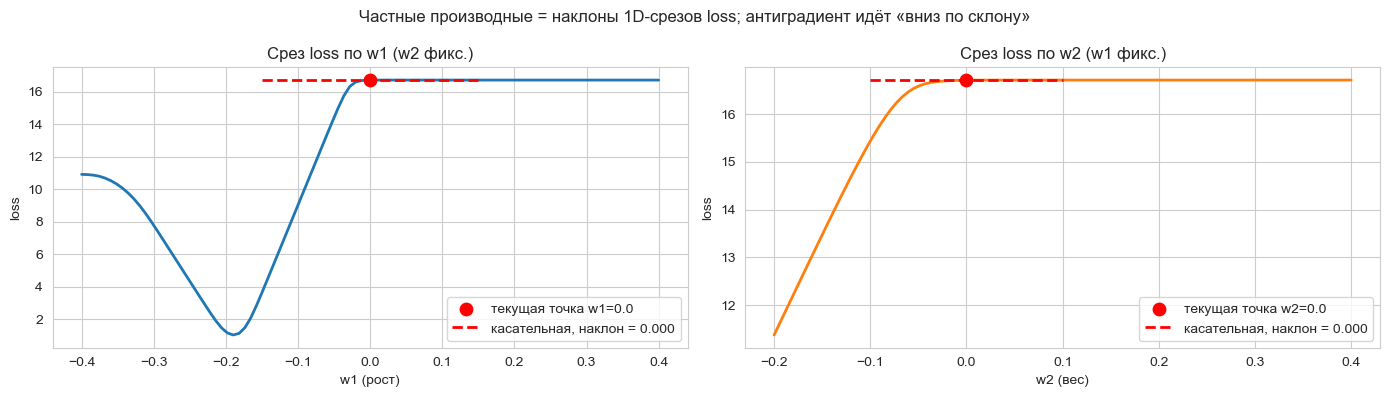


∂L/∂w1 = 0.0000 → w1 надо двигать в сторону увеличения
∂L/∂w2 = 0.0000 → w2 надо двигать в сторону увеличения


In [10]:
w_curr = np.array([0.0, 0.0])
b_curr = b_fixed

w1_grid = np.linspace(-0.4, 0.4, 100)
loss_w1 = [log_loss(X, y, np.array([w1, w_curr[1]]), b_curr) for w1 in w1_grid]

w2_grid = np.linspace(-0.2, 0.4, 100)
loss_w2 = [log_loss(X, y, np.array([w_curr[0], w2]), b_curr) for w2 in w2_grid]

def partial(idx, w, b, eps=1e-5):
    w_plus, w_minus = w.copy(), w.copy()
    w_plus[idx] += eps; w_minus[idx] -= eps
    return (log_loss(X, y, w_plus, b) - log_loss(X, y, w_minus, b)) / (2 * eps)

g1 = partial(0, w_curr, b_curr)
g2 = partial(1, w_curr, b_curr)
L_at_curr = log_loss(X, y, w_curr, b_curr)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(w1_grid, loss_w1, linewidth=2)
axes[0].scatter([w_curr[0]], [L_at_curr], color='red', s=80, zorder=5,
                label=f'текущая точка w1={w_curr[0]}')
tangent_x = np.array([w_curr[0]-0.15, w_curr[0]+0.15])
tangent_y = L_at_curr + g1 * (tangent_x - w_curr[0])
axes[0].plot(tangent_x, tangent_y, 'r--', linewidth=2,
             label=f'касательная, наклон = {g1:.3f}')
axes[0].set_xlabel('w1 (рост)'); axes[0].set_ylabel('loss')
axes[0].set_title('Срез loss по w1 (w2 фикс.)')
axes[0].legend()

axes[1].plot(w2_grid, loss_w2, linewidth=2, color='C1')
axes[1].scatter([w_curr[1]], [L_at_curr], color='red', s=80, zorder=5,
                label=f'текущая точка w2={w_curr[1]}')
tangent_x = np.array([w_curr[1]-0.1, w_curr[1]+0.1])
tangent_y = L_at_curr + g2 * (tangent_x - w_curr[1])
axes[1].plot(tangent_x, tangent_y, 'r--', linewidth=2,
             label=f'касательная, наклон = {g2:.3f}')
axes[1].set_xlabel('w2 (вес)'); axes[1].set_ylabel('loss')
axes[1].set_title('Срез loss по w2 (w1 фикс.)')
axes[1].legend()

plt.suptitle('Частные производные = наклоны 1D-срезов loss; антиградиент идёт «вниз по склону»')
plt.tight_layout()
plt.show()

print(f'\n∂L/∂w1 = {g1:.4f} → w1 надо двигать в сторону {"уменьшения" if g1>0 else "увеличения"}')
print(f'∂L/∂w2 = {g2:.4f} → w2 надо двигать в сторону {"уменьшения" if g2>0 else "увеличения"}')

## Часть 5. Реализация на NumPy

Теперь напишем логистическую регрессию **с нуля**, чтобы на каждом шаге было видно, что происходит. Сохраняем историю весов, чтобы потом нарисовать траекторию по поверхности ошибки.

In [11]:
class LogRegNumpy:
    # Логистическая регрессия с обучением через градиентный спуск (full-batch).

    def __init__(self, lr: float = 0.01, n_epochs: int = 1000):
        self.lr = lr
        self.n_epochs = n_epochs
        self.w = None
        self.b = None
        self.history = {'loss': [], 'w': [], 'b': [], 'acc': []}

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0
        self.history = {'loss': [], 'w': [], 'b': [], 'acc': []}

        for epoch in range(self.n_epochs):
            # forward
            z = X @ self.w + self.b
            y_hat = sigmoid(z)

            # logging
            loss = log_loss(X, y, self.w, self.b)
            acc = ((y_hat > 0.5).astype(int) == y).mean()
            self.history['loss'].append(loss)
            self.history['w'].append(self.w.copy())
            self.history['b'].append(self.b)
            self.history['acc'].append(acc)

            # градиенты — те самые (ŷ-y)·x_j, усреднённые по примерам
            err = y_hat - y
            grad_w = (X.T @ err) / n
            grad_b = err.mean()

            # шаг антиградиентного спуска
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

        return self

    def predict_proba(self, X):
        return sigmoid(X @ self.w + self.b)

    def predict(self, X):
        return (self.predict_proba(X) > 0.5).astype(int)

### Обучаем на немасштабированных данных

`height` ~ 155–200, `weight` ~ 45–120. Чтобы GD не разлетелся, берём очень маленький `lr`.

In [12]:
model_unscaled = LogRegNumpy(lr=1e-4, n_epochs=2000).fit(X, y)
print(f'Финальные веса:    w1={model_unscaled.w[0]:.4f}, w2={model_unscaled.w[1]:.4f}, b={model_unscaled.b:.4f}')
print(f'Финальный loss:    {model_unscaled.history["loss"][-1]:.4f}')
print(f'Точность на train: {model_unscaled.history["acc"][-1]:.3f}')

Финальные веса:    w1=-0.0636, w2=0.1399, b=0.0019
Финальный loss:    0.4450
Точность на train: 0.765


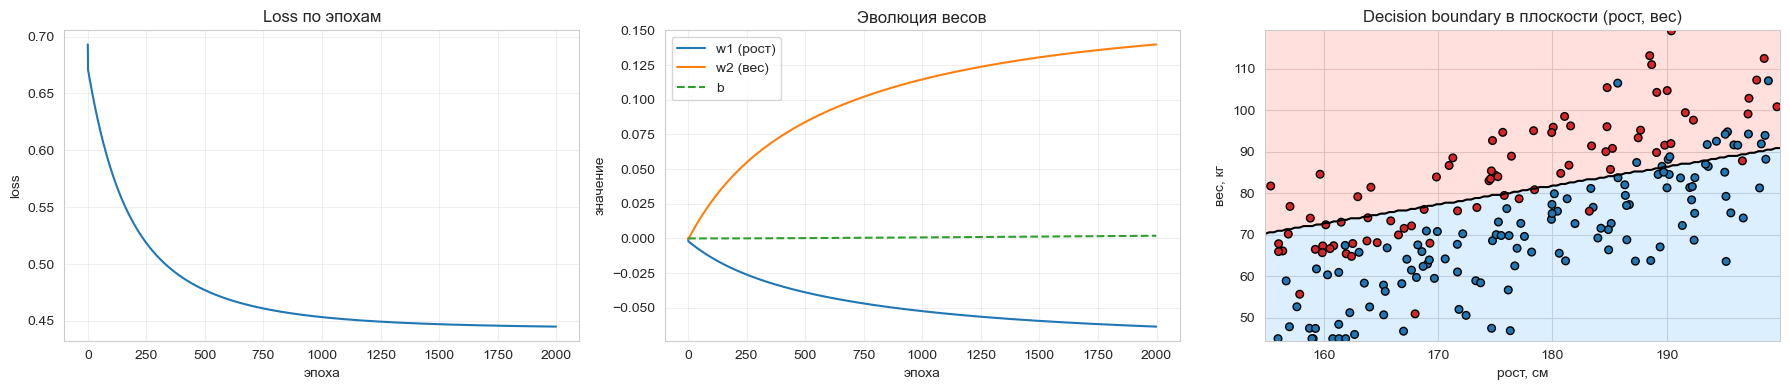

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

plot_loss_curve(model_unscaled.history, ax=axes[0], title='Loss по эпохам')
plot_weight_evolution(model_unscaled.history, ax=axes[1],
                      title='Эволюция весов', weight_names=['w1 (рост)', 'w2 (вес)'])

plot_decision_boundary(model_unscaled.predict, X, y, ax=axes[2],
                       title='Decision boundary в плоскости (рост, вес)',
                       feature_names=('рост, см', 'вес, кг'))
plt.tight_layout()
plt.show()

### Траектория градиентного спуска по поверхности ошибки

Самая красивая визуализация — путь весов $(w_1, w_2)$ по эпохам, нарисованный поверх контурной карты loss. Видно, как обучение «скатывается в овраг».

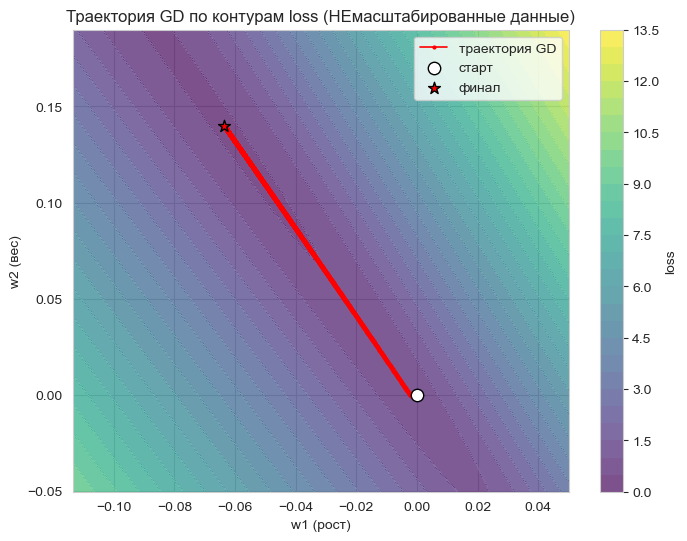

In [14]:
W_hist = np.array(model_unscaled.history['w'])
margin = 0.05
w1_min, w1_max = W_hist[:, 0].min() - margin, W_hist[:, 0].max() + margin
w2_min, w2_max = W_hist[:, 1].min() - margin, W_hist[:, 1].max() + margin
w1_grid = np.linspace(w1_min, w1_max, 60)
w2_grid = np.linspace(w2_min, w2_max, 60)

# для контура фиксируем b на финальном значении модели — иначе видим срез loss не вокруг найденного минимума
b_for_contour = model_unscaled.b
def loss_surface_my_b(w1, w2):
    return log_loss(X, y, np.array([w1, w2]), b_for_contour)

fig, ax = plt.subplots(figsize=(8, 6))
plot_loss_contour(loss_surface_my_b, w1_grid, w2_grid, trajectory=W_hist, ax=ax,
                  title='Траектория GD по контурам loss (НЕмасштабированные данные)',
                  w1_name='w1 (рост)', w2_name='w2 (вес)')
plt.show()

**Видно характерный «овраг»**: контуры вытянуты (потому что `height` и `weight` в разных масштабах), и траектория движется вдоль длинной оси к минимуму.

### Развенчание мифа «ошибка должна стать нулевой»

Распечатаем финальный loss и сравним с теоретически возможным нулём:

In [15]:
print(f'Финальный loss: {model_unscaled.history["loss"][-1]:.4f}')
print(f'Теоретический минимум при идеальной модели: 0')
print()
print('Почему мы не дошли до нуля?')
print('1) В метках есть 5% шума — некоторые точки помечены неправильно по построению.')
print('2) Истинная граница (BMI=25) криволинейная, а мы аппроксимируем её ПРЯМОЙ.')
print('3) Минимум функции — это точка где ∇L = 0. Значение функции в этой точке')
print('   определяется данными. Шумные/неразделимые данные → loss в минимуме > 0.')
print('   Это нормально. GD ищет минимум, а не «обнуляет» ошибку.')

Финальный loss: 0.4450
Теоретический минимум при идеальной модели: 0

Почему мы не дошли до нуля?
1) В метках есть 5% шума — некоторые точки помечены неправильно по построению.
2) Истинная граница (BMI=25) криволинейная, а мы аппроксимируем её ПРЯМОЙ.
3) Минимум функции — это точка где ∇L = 0. Значение функции в этой точке
   определяется данными. Шумные/неразделимые данные → loss в минимуме > 0.
   Это нормально. GD ищет минимум, а не «обнуляет» ошибку.


## Часть 6. Эффект масштабирования (ключевой раздел)

Применим `StandardScaler`: каждый признак становится со средним 0 и стандартным отклонением 1.
Обучим **ту же модель** на масштабированных данных и сравним.

In [16]:
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
print('Среднее по признакам после скейлинга:', X_scaled.mean(axis=0).round(3))
print('Std по признакам после скейлинга:    ', X_scaled.std(axis=0).round(3))

# те же 2000 эпох, но теперь lr=0.1 — сильно крупнее, потому что градиенты теперь маленькие
model_scaled = LogRegNumpy(lr=0.1, n_epochs=2000).fit(X_scaled, y)
print(f'\nФинальные веса (масштабированные): w1={model_scaled.w[0]:.4f}, w2={model_scaled.w[1]:.4f}, b={model_scaled.b:.4f}')
print(f'Финальный loss (масштабированные): {model_scaled.history["loss"][-1]:.4f}')

Среднее по признакам после скейлинга: [-0. -0.]
Std по признакам после скейлинга:     [1. 1.]

Финальные веса (масштабированные): w1=-3.5606, w2=4.4500, b=-0.9225
Финальный loss (масштабированные): 0.2771


### Side-by-side: контурные карты loss и траектории GD

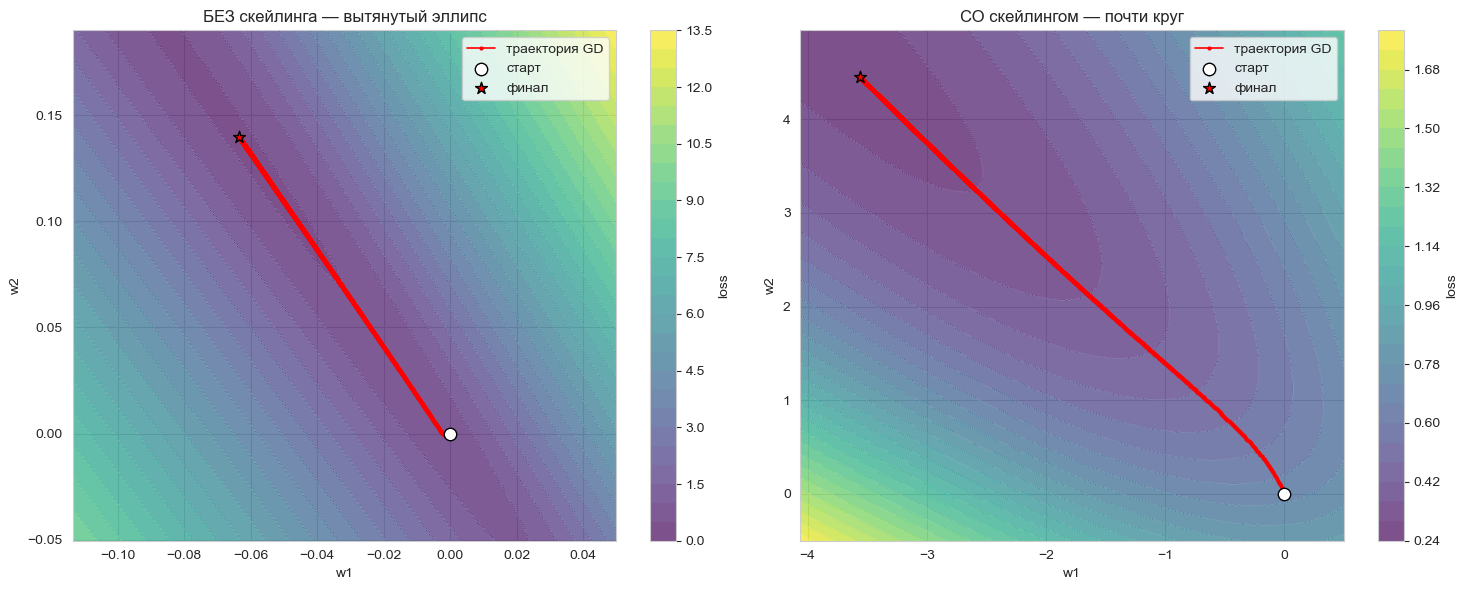

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Слева — немасштабированные
W_hist_unscaled = np.array(model_unscaled.history['w'])
w1_grid = np.linspace(W_hist_unscaled[:,0].min()-0.05, W_hist_unscaled[:,0].max()+0.05, 60)
w2_grid = np.linspace(W_hist_unscaled[:,1].min()-0.05, W_hist_unscaled[:,1].max()+0.05, 60)
b_unsc = model_unscaled.b
def loss_unsc(w1, w2):
    return log_loss(X, y, np.array([w1, w2]), b_unsc)
plot_loss_contour(loss_unsc, w1_grid, w2_grid, trajectory=W_hist_unscaled, ax=axes[0],
                  title='БЕЗ скейлинга — вытянутый эллипс', w1_name='w1', w2_name='w2')

# Справа — масштабированные
W_hist_scaled = np.array(model_scaled.history['w'])
w1_grid = np.linspace(W_hist_scaled[:,0].min()-0.5, W_hist_scaled[:,0].max()+0.5, 60)
w2_grid = np.linspace(W_hist_scaled[:,1].min()-0.5, W_hist_scaled[:,1].max()+0.5, 60)
b_sc = model_scaled.b
def loss_sc(w1, w2):
    return log_loss(X_scaled, y, np.array([w1, w2]), b_sc)
plot_loss_contour(loss_sc, w1_grid, w2_grid, trajectory=W_hist_scaled, ax=axes[1],
                  title='СО скейлингом — почти круг', w1_name='w1', w2_name='w2')

plt.tight_layout()
plt.show()

**Это и есть весь смысл скейлинга в одной картинке.**

Слева: признаки в разных масштабах → градиенты по ним в разных масштабах → loss-поверхность представляет собой **сильно вытянутый эллипс**. GD движется зигзагом или очень медленно по «оврагу».

Справа: признаки одинакового масштаба → градиенты сопоставимы → контуры почти круглые → GD идёт **прямо в минимум**.

### Сравнение скорости сходимости и финальной точности

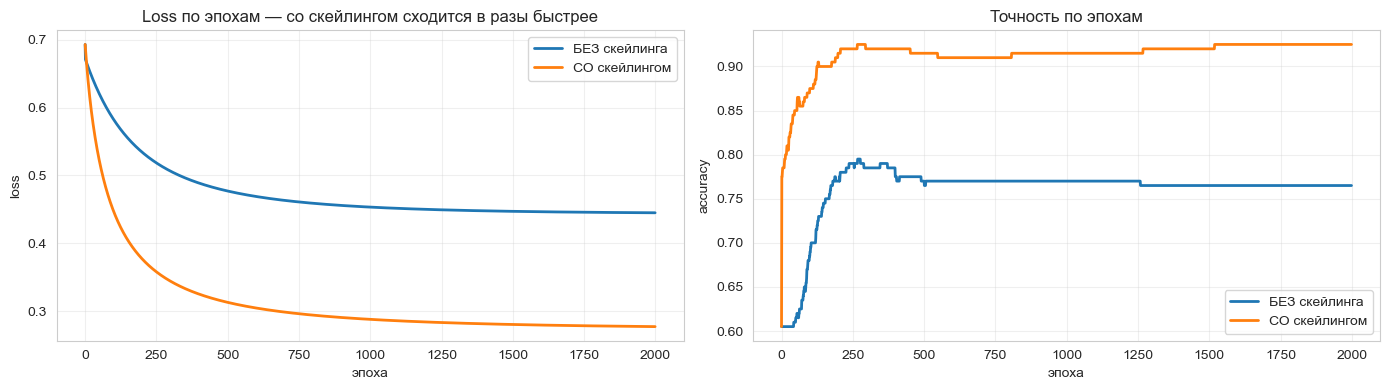

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(model_unscaled.history['loss'], label='БЕЗ скейлинга', linewidth=2)
axes[0].plot(model_scaled.history['loss'], label='СО скейлингом', linewidth=2)
axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('loss')
axes[0].set_title('Loss по эпохам — со скейлингом сходится в разы быстрее')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(model_unscaled.history['acc'], label='БЕЗ скейлинга', linewidth=2)
axes[1].plot(model_scaled.history['acc'], label='СО скейлингом', linewidth=2)
axes[1].set_xlabel('эпоха'); axes[1].set_ylabel('accuracy')
axes[1].set_title('Точность по эпохам')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Сравнение весов: «изменилась ли модель?»

Веса в обеих моделях **разные по числам**, но если перевести масштабированные обратно в исходное пространство — они описывают **одну и ту же разделяющую прямую**. Скейлинг — это просто смена системы координат, физика та же.

Формула обратного перевода:

$$
w_j^{\text{orig}} = \frac{w_j^{\text{scaled}}}{\sigma_j}, \qquad
b^{\text{orig}} = b^{\text{scaled}} - \sum_j \frac{w_j^{\text{scaled}} \cdot \mu_j}{\sigma_j}
$$

In [19]:
mu = scaler.mean_
sigma = scaler.scale_
w_scaled_back = model_scaled.w / sigma
b_scaled_back = model_scaled.b - np.sum(model_scaled.w * mu / sigma)

print('Веса, обученные на немасштабированных:')
print(f'  w1={model_unscaled.w[0]:.5f}, w2={model_unscaled.w[1]:.5f}, b={model_unscaled.b:.4f}')
print()
print('Веса, обученные на масштабированных:')
print(f'  w1={model_scaled.w[0]:.5f}, w2={model_scaled.w[1]:.5f}, b={model_scaled.b:.4f}')
print()
print('Веса со скейлинга, переведённые обратно в исходные координаты:')
print(f'  w1={w_scaled_back[0]:.5f}, w2={w_scaled_back[1]:.5f}, b={b_scaled_back:.4f}')
print()
print('Они должны быть близки к весам, обученным напрямую без скейлинга')
print('(точное совпадение зависит от того, насколько обе модели сошлись).')

Веса, обученные на немасштабированных:
  w1=-0.06363, w2=0.13993, b=0.0019

Веса, обученные на масштабированных:
  w1=-3.56060, w2=4.44998, b=-0.9225

Веса со скейлинга, переведённые обратно в исходные координаты:
  w1=-0.28098, w2=0.28028, b=27.7233

Они должны быть близки к весам, обученным напрямую без скейлинга
(точное совпадение зависит от того, насколько обе модели сошлись).


## Часть 7. Эффект learning rate

Покажем 3 значения lr на масштабированных данных: слишком маленький, нормальный, слишком большой.

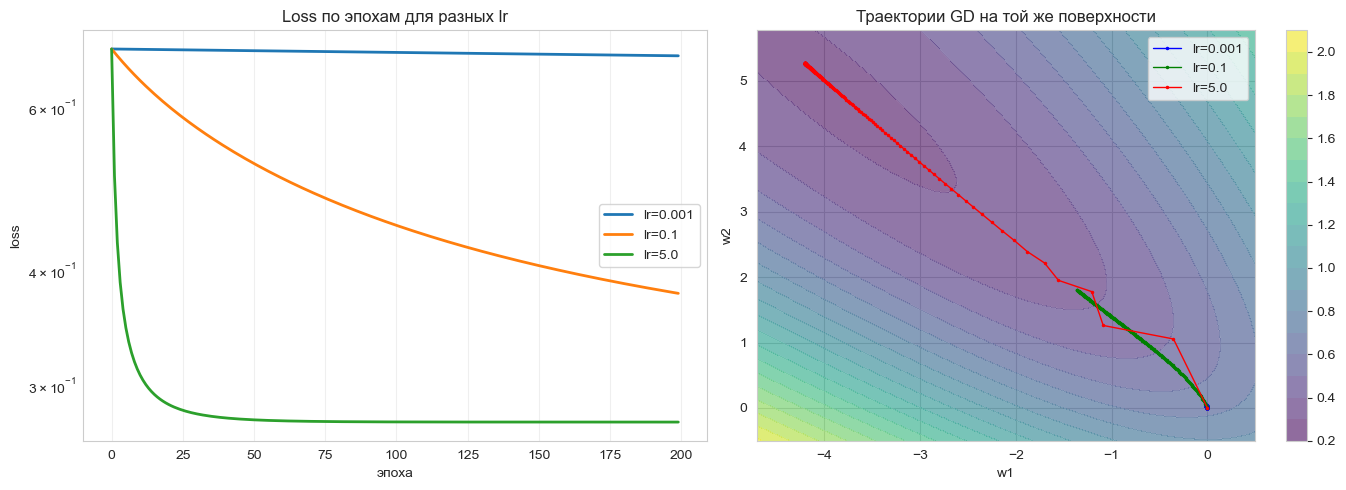

In [20]:
lrs = [0.001, 0.1, 5.0]
labels = [f'lr={lr}' for lr in lrs]
models_by_lr = [LogRegNumpy(lr=lr, n_epochs=200).fit(X_scaled, y) for lr in lrs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Слева — кривые loss
for m, lbl in zip(models_by_lr, labels):
    axes[0].plot(m.history['loss'], label=lbl, linewidth=2)
axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('loss')
axes[0].set_title('Loss по эпохам для разных lr')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_yscale('log')

# Справа — траектории на контуре
W_all = np.concatenate([np.array(m.history['w']) for m in models_by_lr])
w1_grid = np.linspace(W_all[:,0].min()-0.5, W_all[:,0].max()+0.5, 60)
w2_grid = np.linspace(W_all[:,1].min()-0.5, W_all[:,1].max()+0.5, 60)
def loss_for_lr(w1, w2):
    return log_loss(X_scaled, y, np.array([w1, w2]), models_by_lr[1].b)

W1g, W2g = np.meshgrid(w1_grid, w2_grid)
L = np.array([[loss_for_lr(a, b) for a in w1_grid] for b in w2_grid])
cs = axes[1].contourf(W1g, W2g, L, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(W1g, W2g, L, levels=20, colors='white', linewidths=0.4, alpha=0.4)
plt.colorbar(cs, ax=axes[1])

colors_traj = ['blue', 'green', 'red']
for m, lbl, c in zip(models_by_lr, labels, colors_traj):
    W = np.array(m.history['w'])
    axes[1].plot(W[:, 0], W[:, 1], '.-', color=c, label=lbl, markersize=3, linewidth=1)
axes[1].set_xlabel('w1'); axes[1].set_ylabel('w2')
axes[1].set_title('Траектории GD на той же поверхности')
axes[1].legend()

plt.tight_layout()
plt.show()

- **Маленький lr (0.001):** мелкие шажки, не дошли до минимума за 200 эпох — нужно больше итераций.
- **Нормальный lr (0.1):** плавно сходимся в минимум.
- **Слишком большой lr (5.0):** перепрыгиваем минимум, loss растёт или скачет — **расходимость**.

## Часть 8. Сравнение с sklearn

Для проверки, что наша numpy-реализация делает то же, что и sklearn:

In [21]:
sk = LogisticRegression(penalty=None, max_iter=10000).fit(X_scaled, y)

print('Наш numpy:')
print(f'  w = {model_scaled.w}, b = {model_scaled.b:.4f}')
print(f'  accuracy = {(model_scaled.predict(X_scaled) == y).mean():.3f}')
print()
print('sklearn LogisticRegression(penalty=None):')
print(f'  w = {sk.coef_[0]}, b = {sk.intercept_[0]:.4f}')
print(f'  accuracy = {sk.score(X_scaled, y):.3f}')
print()
print('Веса должны почти совпасть. Различие — из-за разных оптимизаторов')
print('(у sklearn это L-BFGS, у нас простой GD), но физический смысл идентичен.')

Наш numpy:
  w = [-3.56060286  4.44998184], b = -0.9225
  accuracy = 0.925

sklearn LogisticRegression(penalty=None):
  w = [-4.21664421  5.28376143], b = -1.0601
  accuracy = 0.925

Веса должны почти совпасть. Различие — из-за разных оптимизаторов
(у sklearn это L-BFGS, у нас простой GD), но физический смысл идентичен.


## Чеклист «понял ли я» (самопроверка)

Если ты можешь ответить на эти вопросы своими словами — глава освоена:

1. Почему градиент по $w_j$ пропорционален $x_j$? *(цепное правило: $\partial \ell / \partial w_j = (\hat{y}-y) \cdot x_j$)*
2. Что произойдёт с весом признака, у которого $x_j = 0$ для всех примеров? *(не изменится никогда)*
3. Что определяет ЗНАК обновления веса? *(знак произведения $(\hat{y}-y) \cdot x_j$)*
4. Что такое «минимум функции ошибки»? Это всегда ноль? *(нет; точка где $\nabla\mathcal{L}=0$, значение зависит от шумности данных)*
5. Что lr **не** делает? *(не «берёт процент от ошибки» — он умножается на градиент)*
6. Почему без скейлинга loss-поверхность вытянута в эллипс? *(градиенты по разным признакам в разных масштабах из-за разных $x_j$)*
7. Изменится ли разделяющая прямая, если перевести веса со скейлинга обратно в исходные координаты? *(нет — это та же геометрическая граница)*
8. Что произойдёт при слишком большом lr? *(перепрыгиваем минимум, loss растёт, GD расходится)*

Дальше → ноутбук **`03_ensembles_intuition.ipynb`**: возьмём те же два датасета и разберём, что физически делают деревья, случайный лес, бэггинг, бустинг и стекинг.